## Superstore Sales Analysis

This project analyzes sales data from a global superstore to uncover trends, profitability drivers, and actionable insights for business optimization.

## Objective

- Analyze sales performance by region, category, and customer segment
- Identify high-profit and loss-making products
- Discover trends over time to assist in forecasting
- Provide data-driven business recommendations

## Tools & Libraries

- Python, Pandas, Numpy
- Matplotlib, Seaborn, Plotly
- Jupyter Notebook

## Project Workflow

1. **Import Libraries & Load Data**
2. **Data Overview & Cleaning**
3. **Exploratory Data Analysis (EDA)**
4. **Feature Engineering**
5. **Data Visualization**
6. **Insights & Recommendations**
7. **Conclusion**

### 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:/Users/Admin/Desktop/Superstore.csv", encoding='ISO-8859-1')

In [18]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [4]:
# Check the shape of the dataset (rows, columns)
print(df.shape)

# View basic statistics for numerical columns
print(df.describe())

(9994, 21)
            Row ID   Postal Code         Sales     Quantity     Discount  \
count  9994.000000   9994.000000   9994.000000  9994.000000  9994.000000   
mean   4997.500000  55190.379428    229.858001     3.789574     0.156203   
std    2885.163629  32063.693350    623.245101     2.225110     0.206452   
min       1.000000   1040.000000      0.444000     1.000000     0.000000   
25%    2499.250000  23223.000000     17.280000     2.000000     0.000000   
50%    4997.500000  56430.500000     54.490000     3.000000     0.200000   
75%    7495.750000  90008.000000    209.940000     5.000000     0.200000   
max    9994.000000  99301.000000  22638.480000    14.000000     0.800000   

            Profit  
count  9994.000000  
mean     28.656896  
std     234.260108  
min   -6599.978000  
25%       1.728750  
50%       8.666500  
75%      29.364000  
max    8399.976000  


## CHECKING FOR NULL VALUES

In [5]:
# Check for missing values in each column
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


## CHECKING FOR DUPLICATE VALUES

In [6]:
# Check for duplicate rows
duplicate_rows = df[df.duplicated()]

# Optionally, view the duplicates
print(duplicate_rows)

Empty DataFrame
Columns: [Row ID, Order ID, Order Date, Ship Date, Ship Mode, Customer ID, Customer Name, Segment, Country, City, State, Postal Code, Region, Product ID, Category, Sub-Category, Product Name, Sales, Quantity, Discount, Profit]
Index: []

[0 rows x 21 columns]


## MONTHLY TOTAL SALES OVER TIME (LINE CHART)

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


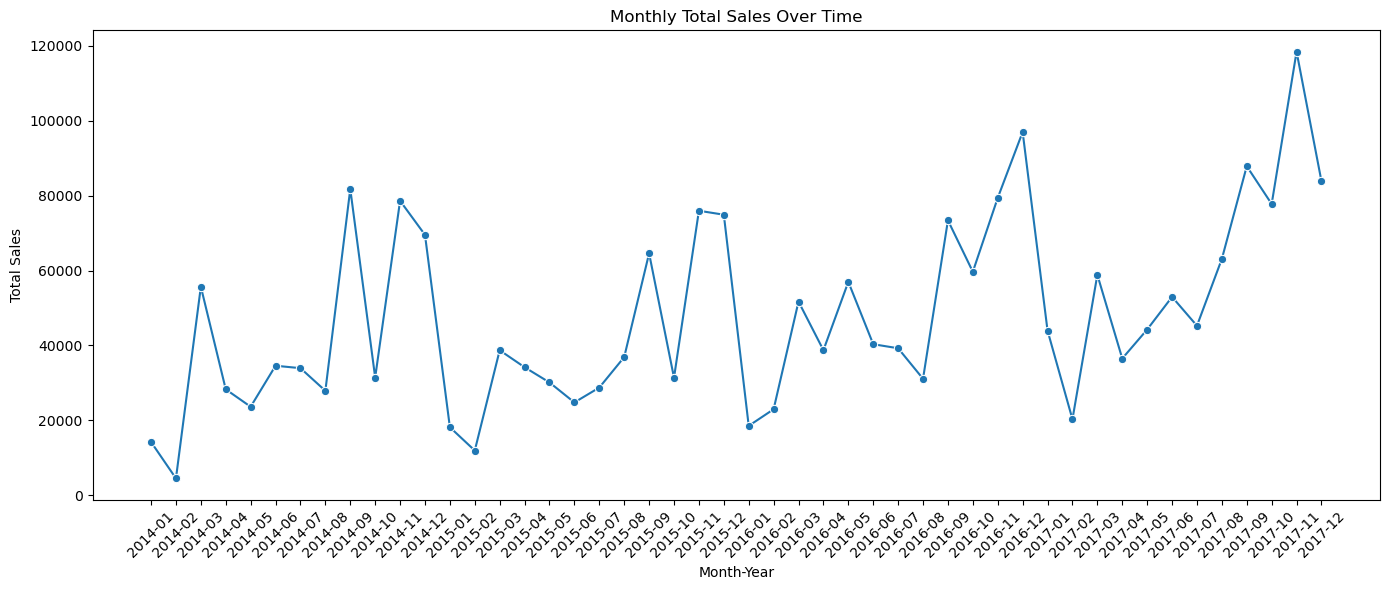

In [10]:
# Create 'Month-Year' column
df['Month-Year'] = df['Order Date'].dt.to_period('M').astype(str)

# Aggregate sales
monthly_sales = df.groupby('Month-Year')['Sales'].sum().reset_index()

# Plot
plt.figure(figsize=(14,6))
sns.lineplot(data=monthly_sales, x='Month-Year', y='Sales', marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Total Sales Over Time')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

## TOTAL PROFIT BY CATEGORY (BAR CHART)

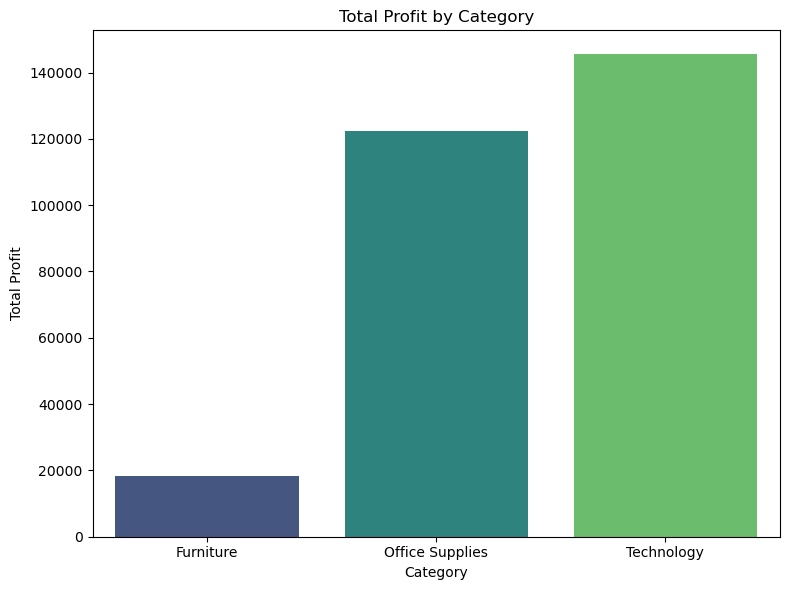

In [11]:
category_profit = df.groupby('Category')['Profit'].sum().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data=category_profit, x='Category', y='Profit', palette='viridis')
plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.tight_layout()
plt.show()

## AVERAGE SALES BY REGION AND SEGMENT (HEAT MAP)

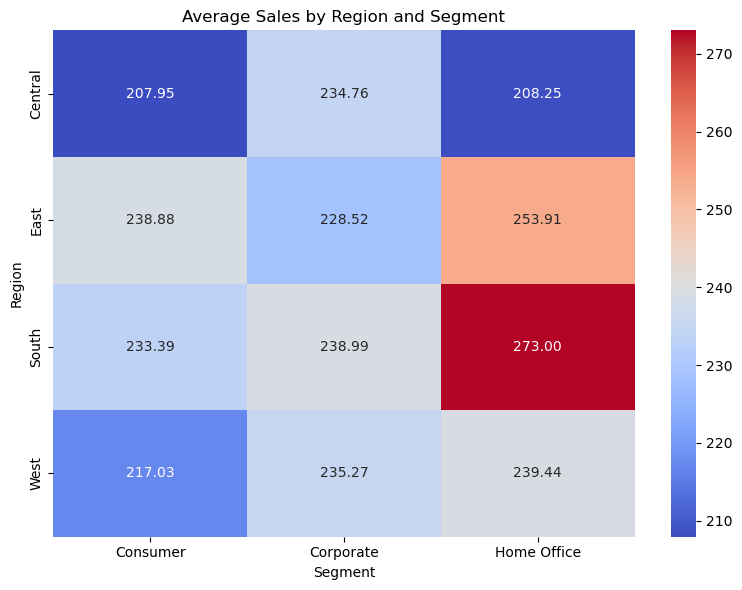

In [12]:
region_segment_sales = df.groupby(['Region', 'Segment'])['Sales'].mean().unstack()

plt.figure(figsize=(8,6))
sns.heatmap(region_segment_sales, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Average Sales by Region and Segment')
plt.xlabel('Segment')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

## TOTAL SALES BY REGION

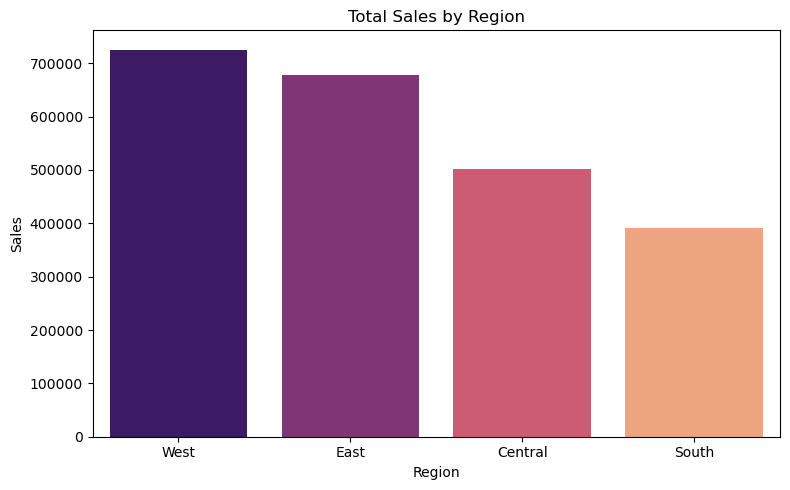

In [13]:
# Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=region_sales.index, y=region_sales.values, palette='magma')
plt.title("Total Sales by Region")
plt.ylabel("Sales")
plt.xlabel("Region")
plt.tight_layout()
plt.show()

## DELIVERY TIME DISTRIBUTION BY SHIP MODE

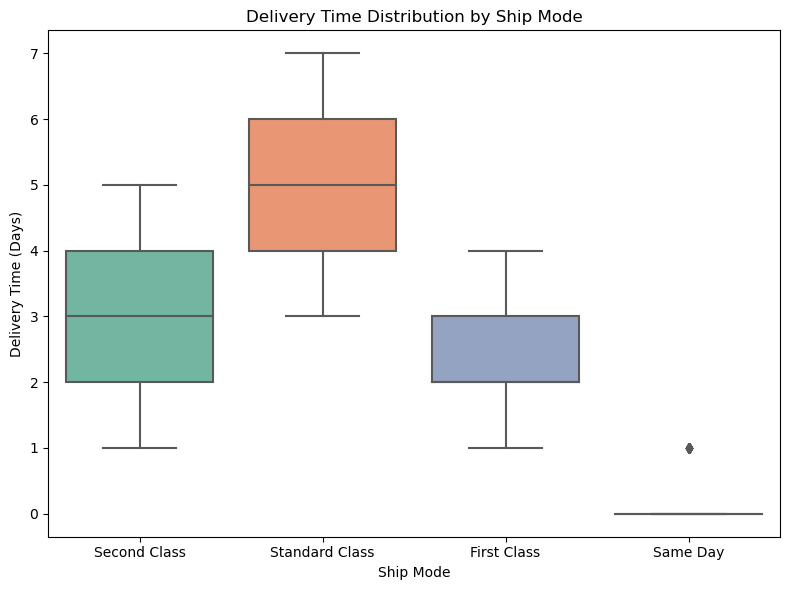

In [14]:
# datetime conversion
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Calculate delivery time
df['Delivery Time'] = (df['Ship Date'] - df['Order Date']).dt.days

# Plot boxplot
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='Ship Mode', y='Delivery Time', palette='Set2')
plt.title('Delivery Time Distribution by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Delivery Time (Days)')
plt.tight_layout()
plt.show()

## CORRELATION BETWEEN: SALES, PROFIT AND DISCOUNT

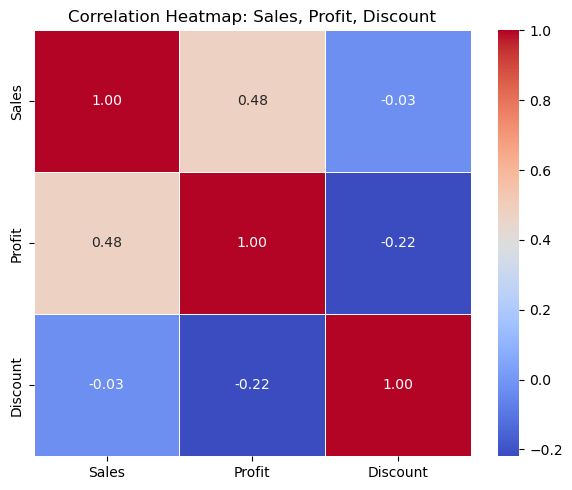

In [15]:
# Select relevant columns
corr_data = df[['Sales', 'Profit', 'Discount']]

# Compute correlation matrix
corr_matrix = corr_data.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Sales, Profit, Discount")
plt.tight_layout()
plt.show()

## SALES BY SEGMENT

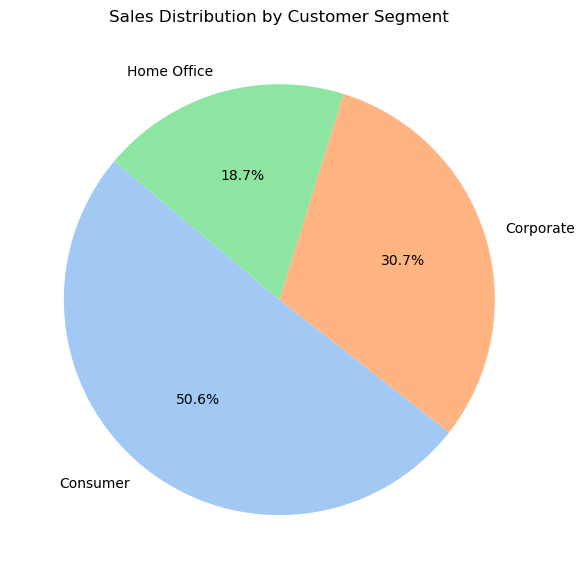

In [16]:
# Sales by Segment
segment_sales = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(6, 6))
plt.pie(segment_sales, labels=segment_sales.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title("Sales Distribution by Customer Segment")
plt.tight_layout()
plt.show()

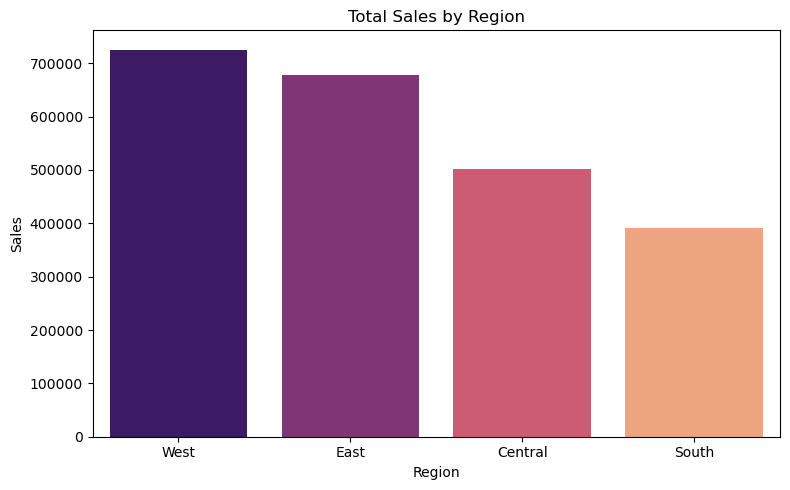

In [17]:
# Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=region_sales.index, y=region_sales.values, palette='magma')
plt.title("Total Sales by Region")
plt.ylabel("Sales")
plt.xlabel("Region")
plt.tight_layout()
plt.show()

## Conclusion & Key Insights

- The **West region** showed the highest profit margins, while **Central** had higher losses.
- **Technology** and **Office Supplies** categories were the most profitable overall.
- Discounts beyond 30% significantly reduced profitability.
- Customer Segment **Corporate** yielded the highest profit-to-sales ratio.

## Recommendation
Optimize discounts and focus marketing on high-margin categories.